In [ ]:

%pip install --upgrade  langchain langchain-google-genai "langchain[docarray]" faiss-cpu pypdf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.1/112.1 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 79.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 332.2/332.2 kB 26.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 16.0 MB/s eta 0:00:00
  Attempting uninstall: langgraph
    Found existing installation: langgraph 1.0.10
    Uninstalling langgraph-1.0.10:
      Successfully uninstalled langgraph-1.0.10
  Attempting uninstall: langchain
    Found existing installation: langchain 1.2.10
    Uninstalling langchain-1.2.10:
      Successfully uninstalled langchain-1.2.10


In [ ]:
import os
import requests
from PIL import Image

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from IPython.display import display, Markdown

In [ ]:
from langchain_google_genai import ChatGoogleGenerativeAI

In [ ]:
from langchain_core.messages import HumanMessage, SystemMessage

In [ ]:
!pip install langchain-community

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 33.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 63.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 5.0 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.


In [ ]:
from langchain_community.vectorstores import DocArrayInMemorySearch

In [ ]:
from langchain_google_genai import GoogleGenerativeAIEmbeddings

In [ ]:

from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate


In [ ]:

from langchain_core.documents import Document
from langchain_community.document_loaders import TextLoader

In [ ]:
from langchain_text_splitters import CharacterTextSplitter

In [ ]:

from langchain_community.vectorstores import FAISS

In [ ]:
from google.colab import userdata
GOOGLE_API_KEY=userdata.get('GEMINI_API_KEY')
os.environ["GEMINI_API_KEY"] = GOOGLE_API_KEY

In [ ]:
def load_model():
    llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")
    return llm

In [ ]:
model_text = load_model()

In [ ]:
model_text.invoke("what is machine learning?").content

'Machine Learning (ML) is a subfield of Artificial Intelligence (AI) that focuses on enabling computers to **learn from data without being explicitly programmed** for every task.\n\nInstead of a human programmer writing specific instructions for every possible scenario, ML algorithms are designed to **identify patterns and relationships within large datasets**. Once trained on this data, the computer can then use these learned patterns to make predictions, decisions, or perform tasks on new, unseen data.\n\n**Here\'s a breakdown of the core idea:**\n\n1.  **Data is Key:** ML models learn from examples. The more relevant and diverse the data, the better the model can learn. This data can be images, text, numbers, audio, etc.\n2.  **Algorithms:** These are the "recipes" or mathematical procedures that the computer uses to find patterns in the data. Examples include linear regression, decision trees, support vector machines, and neural networks.\n3.  **Training:** This is the process wher

In [ ]:
message=HumanMessage(content="Answer with Simple 'Yes' or 'No'. Question: Is apple a Fruit?")

In [ ]:
response= model_text.invoke([message])

In [ ]:
print(response)

content='Yes' additional_kwargs={} response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'} id='lc_run--019cd8c6-2c99-7dd3-af56-8cb3641fea31-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 18, 'output_tokens': 50, 'total_tokens': 68, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 49}}


In [ ]:
print(response.content)

Yes


In [ ]:

def get_image(url,filename,extension):
  content = requests.get(url).content
  with open(f'/content/{filename}.{extension}', 'wb') as f:
    f.write(content)
  image = Image.open(f"/content/{filename}.{extension}")
  image.show()
  return image


In [ ]:
image = get_image("https://static.nike.com/a/images/t_PDP_1728_v1/f_auto,q_auto:eco/1705ca64-fbc8-4b79-a451-4ab77760c219/dunk-low-older-shoes-C7T1cx.png",
                  "nike-shoes",
                  "png")



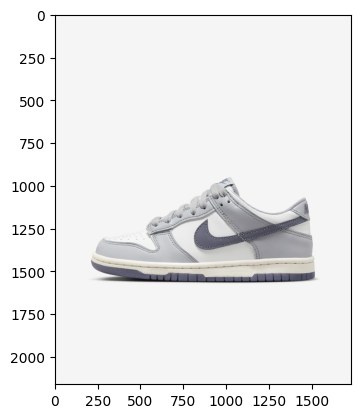

In [ ]:
plt.imshow(image)
plt.show()

In [ ]:
vision_model=load_model()

In [ ]:
prompt="give me summary of this image in 10 words"

In [ ]:
import base64
from io import BytesIO
from langchain_core.messages import HumanMessage


def image_to_base64(image):
    buffered = BytesIO()
    image.save(buffered, format="JPEG")
    img_str = base64.b64encode(buffered.getvalue()).decode("utf-8")
    return f"data:image/jpeg;base64,{img_str}"


img_base64 = image_to_base64(image)


message = HumanMessage(
    content=[
        {
            "type": "image_url",
            "image_url": {"url": img_base64}
        }
    ]
)


print(vision_model.invoke([message]).content)

```json
[
  {"box_2d": [182, 117, 727, 878], "label": "the shoe"}
]
```


In [ ]:
import base64
from io import BytesIO
from langchain_core.messages import HumanMessage


def image_to_base64(image):
    buffered = BytesIO()
    image.save(buffered, format="JPEG")
    img_str = base64.b64encode(buffered.getvalue()).decode("utf-8")
    return f"data:image/jpeg;base64,{img_str}"


img_base64 = image_to_base64(image)


message = HumanMessage(
    content=[
        {
            "type": "text",
            "text": prompt
        },
        {
            "type": "image_url",
            "image_url": {"url": img_base64}
        }
    ]
)

print(vision_model.invoke([message]).content)

Nike Dunk Low sneaker, white with light and dark grey.


In [ ]:
loader = TextLoader("/content/nikeshoes (1).txt")
print(loader.load()[0].page_content)

Nike Shoes Product Catalog - RAG Knowledge Base

## Nike Air Max 270
- Type: Lifestyle / Running
- Price: $150
- Colors: Black/White, Triple White, Red/Black, Blue/White
- Features:
  - Largest Air unit in heel for maximum cushioning
  - Mesh upper for breathability
  - Foam midsole for lightweight comfort
  - Rubber outsole for durability
- Best For: Everyday wear, casual outings, light jogging
- Sizes Available: US 6 to US 15
- Weight: 11.4 oz (size 10)

## Nike Air Force 1
- Type: Lifestyle / Casual
- Price: $110
- Colors: Triple White, Triple Black, University Red, Royal Blue, Custom Colors
- Features:
  - Classic leather upper
  - Nike Air cushioning in sole
  - Pivot circle rubber outsole
  - Padded ankle collar
- Best For: Streetwear, casual everyday use
- Sizes Available: US 3.5 to US 18
- Weight: 13 oz (size 10)
- Fun Fact: One of Nike's best-selling shoes of all time, launched in 1982

## Nike React Infinity Run Flyknit 3
- Type: Running
- Price: $160
- Colors: Black/White, V

In [ ]:
text=loader.load()[0].page_content

In [ ]:
def get_text_chunks_langchain(text):
  text_splitter = CharacterTextSplitter(chunk_size=20, chunk_overlap=10)
  docs = [Document(page_content=x) for x in text_splitter.split_text(text)]
  return docs

In [ ]:
docs = get_text_chunks_langchain(text)

In [ ]:
embeddings = GoogleGenerativeAIEmbeddings(model="gemini-embedding-2-preview")

In [ ]:
vectorstore = FAISS.from_documents(docs,embedding=embeddings)

In [ ]:
retriever=vectorstore.as_retriever()

In [ ]:

response=retriever.invoke(" Nike Air Max 270")

In [ ]:
response

[Document(id='c58fd63e-a979-480a-b8b6-2caf530bbb11', metadata={}, page_content='## Nike Air Max 270\n- Type: Lifestyle / Running\n- Price: $150\n- Colors: Black/White, Triple White, Red/Black, Blue/White\n- Features:\n  - Largest Air unit in heel for maximum cushioning\n  - Mesh upper for breathability\n  - Foam midsole for lightweight comfort\n  - Rubber outsole for durability\n- Best For: Everyday wear, casual outings, light jogging\n- Sizes Available: US 6 to US 15\n- Weight: 11.4 oz (size 10)'),
 Document(id='5bc52b3e-480e-456a-b131-cf2f1075ef87', metadata={}, page_content="Q: What is Nike's most popular shoe?\nA: The Nike Air Force 1 is one of Nike's best-selling and most iconic shoes, followed closely by the Air Max 270 and Dunk Low."),
 Document(id='0e9f3160-65ae-4bb9-8c40-e73a5660b1d3', metadata={}, page_content='## Nike Technology Overview'),
 Document(id='89ff5ebd-02ca-4e31-ad96-23e9161726ac', metadata={}, page_content='## Nike Size Guide\n| US Size | UK Size | EU Size | CM |

In [ ]:
for doc in response:
  print(doc.page_content)

## Nike Air Max 270
- Type: Lifestyle / Running
- Price: $150
- Colors: Black/White, Triple White, Red/Black, Blue/White
- Features:
  - Largest Air unit in heel for maximum cushioning
  - Mesh upper for breathability
  - Foam midsole for lightweight comfort
  - Rubber outsole for durability
- Best For: Everyday wear, casual outings, light jogging
- Sizes Available: US 6 to US 15
- Weight: 11.4 oz (size 10)
Q: What is Nike's most popular shoe?
A: The Nike Air Force 1 is one of Nike's best-selling and most iconic shoes, followed closely by the Air Max 270 and Dunk Low.
## Nike Technology Overview
## Nike Size Guide
| US Size | UK Size | EU Size | CM |
|---------|---------|---------|-----|
| 6       | 5.5     | 38.5    | 24  |
| 7       | 6       | 40      | 25  |
| 8       | 7       | 41      | 26  |
| 9       | 8       | 42.5    | 27  |
| 10      | 9       | 44      | 28  |
| 11      | 10      | 45      | 29  |
| 12      | 11      | 46.5    | 30  |


In [ ]:
from langchain_core.runnables import RunnableLambda, RunnablePassthrough

In [ ]:



llm_vision = load_model()

In [ ]:

llm_text = load_model()

In [ ]:
template = """
```
{context}
```

{query}


Provide brief information and also about the price .
"""

In [ ]:
prompt = ChatPromptTemplate.from_template(template)



In [ ]:
rag_chain = (
    {"context": retriever, "query": RunnablePassthrough()}
    | prompt
    | llm_text
    | StrOutputParser()
)

In [ ]:
result = rag_chain.invoke("can you give me a detail of Nike Air Force 1?")

In [ ]:
display(Markdown(result))

The Nike Air Force 1 is a classic lifestyle/casual shoe, **priced at $110**.

It features a classic leather upper, Nike Air cushioning in the sole, a pivot circle rubber outsole, and a padded ankle collar. It's best suited for streetwear and casual everyday use and is available in various colors like Triple White, Triple Black, University Red, Royal Blue, and custom options.

Launched in 1982, it's one of Nike's best-selling and most iconic shoes of all time.

In [ ]:
rag_chain


{
  context: VectorStoreRetriever(tags=['FAISS', 'GoogleGenerativeAIEmbeddings'], vectorstore=<langchain_community.vectorstores.faiss.FAISS object at 0x792436314080>, search_kwargs={}),
  query: RunnablePassthrough()
}
| ChatPromptTemplate(input_variables=['context', 'query'], input_types={}, partial_variables={}, messages=[HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['context', 'query'], input_types={}, partial_variables={}, template='\n```\n{context}\n```\n\n{query}\n\n\nProvide brief information and also about the price .\n'), additional_kwargs={})])
| ChatGoogleGenerativeAI(profile={'max_input_tokens': 1048576, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': True, 'pdf_inputs': True, 'video_inputs': True, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'image_url_inputs': True, 'image_tool_message': True

In [ ]:

full_chain = (
    RunnablePassthrough() | llm_vision | StrOutputParser() | rag_chain
)


In [ ]:
import re

def ensure_query(text):
    if text is None or len(text.strip()) == 0:
        return "shoe brand and model information"

    # Extract brand and model using regex
    brand_match = re.search(r'\*\*Brand:\*\* (.*?)\n', text)
    model_match = re.search(r'\*\*Model:\*\* (.*?)\n', text)

    brand = brand_match.group(1).strip() if brand_match else ""
    model = model_match.group(1).strip() if model_match else ""

    if brand and model:
        return f"{brand} {model}"
    elif brand:
        return brand
    elif model:
        return model
    else:
        return "shoe brand and model information"

In [ ]:
full_chain = (
    RunnablePassthrough()
    | llm_vision
    | StrOutputParser()
    | RunnableLambda(ensure_query)
    | rag_chain
)

In [ ]:
full_chain



RunnablePassthrough()
| ChatGoogleGenerativeAI(profile={'max_input_tokens': 1048576, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': True, 'pdf_inputs': True, 'video_inputs': True, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'image_url_inputs': True, 'image_tool_message': True, 'tool_choice': True}, google_api_key=SecretStr('**********'), model='gemini-2.5-flash', client=<google.genai.client.Client object at 0x79243f3d95e0>, default_metadata=(), model_kwargs={})
| StrOutputParser()
| RunnableLambda(ensure_query)
| {
    context: VectorStoreRetriever(tags=['FAISS', 'GoogleGenerativeAIEmbeddings'], vectorstore=<langchain_community.vectorstores.faiss.FAISS object at 0x792436314080>, search_kwargs={}),
    query: RunnablePassthrough()
  }
| ChatPromptTemplate(input_variables=['context', 'query'], input_types={}, partial_variable

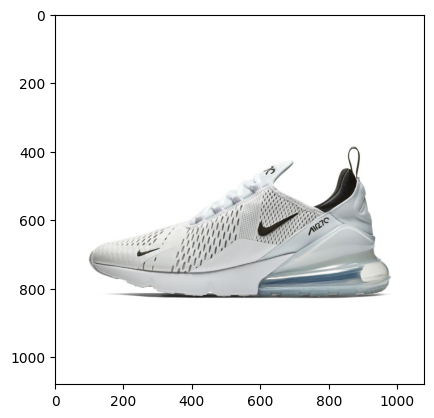

In [ ]:
url_1="https://adn-static1.nykaa.com/nykdesignstudio-images/pub/media/catalog/product/5/3/5324c8eNike-AH8050-100_1.jpg?rnd=20200526195200&tr=w-1080"
image = get_image(url_1, "nike2", "png")
plt.imshow(image)

plt.show()

In [ ]:
import base64
from io import BytesIO
from langchain_core.messages import HumanMessage


def image_to_base64(image):
    buffered = BytesIO()
    image.save(buffered, format="JPEG")
    img_str = base64.b64encode(buffered.getvalue()).decode("utf-8")
    return f"data:image/jpeg;base64,{img_str}"


img_base64 = image_to_base64(image)
message = HumanMessage(
    content=[
        {
            "type": "text",
            "text": "Provide information on given shoe image Brand and model.",
        },
        {
            "type": "image_url",
            "image_url": {"url": img_base64}
        }
    ]
)




In [ ]:
result = full_chain.invoke([message])

In [ ]:
display(Markdown(result))

The Nike Air Max 270 is priced at **$150**.

It is a lifestyle/running shoe known for its largest Air unit in the heel, providing maximum cushioning. It also features a mesh upper for breathability, a foam midsole for lightweight comfort, and a durable rubber outsole. It's best for everyday wear, casual outings, and light jogging.